# Метрики и результаты

Сводка по артефактам анализов. Тетрадь ничего не обучает и не скорит — только читает
JSON/CSV, которые пишут скрипты `analysis_*.py`, и показывает картину целиком.

Порядок соответствует логике вопросов: правильная ли у нас метка → есть ли вообще
сигнал в метке → сколько его забирает модель → бьёт ли она дешёвые альтернативы →
не выучила ли она причуды одного оракула → сколько это экономит на практике.

Если какого-то файла нет, соответствующий раздел сообщит, какой скрипт запустить.

In [1]:
# Подъём до корня репозитория (тетрадь открывается в notebooks/)
import os
while not os.path.exists("inference.py") and os.getcwd() != os.path.dirname(os.getcwd()):
    os.chdir("..")
assert os.path.exists("inference.py"), "Откройте тетрадь внутри репозитория BbValidator"
print("Корень репозитория:", os.getcwd())

Корень репозитория: /home/pc/PycharmProjects/BbValidator


In [2]:
%matplotlib inline
import json

import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams.update({"figure.figsize": (10, 4), "axes.grid": True, "grid.alpha": 0.3})
GENS = ["RFdiffusion", "RFdiffusion-AA", "ODesign-Rigid", "GPDL", "EvoDiff"]
HOLDOUT = {"ODesign-Rigid", "GPDL"}


def load(path, script):
    if not os.path.exists(path):
        print(f"нет {path} — запустите: python -m {script}")
        return None
    with open(path, encoding="utf-8") as fp:
        return json.load(fp)

## 1. Выбор метки: mean против min

`docs/07` определяет метрику MotifBench как $\min_k$ по восьми последовательностям,
а код до 2026-08-13 считал среднее. Распределение per-sequence RMSD бимодально
(либо ~1 Å, либо >6 Å), поэтому среднее измеряет **долю удачных последовательностей**,
а не дизайнируемость остова.

Проверяем цену перехода: не выросла ли зашумлённость метки.

In [3]:
lc = load("results/analysis_label_choice.json", "analysis.label_choice")
if lc:
    rows = []
    for g in GENS:
        r = lc[g]
        rows.append({
            "генератор": g,
            "дизайн. mean": f"{r['mean']['pooled_base_rate']:.1%}",
            "дизайн. min": f"{r['min']['pooled_base_rate']:.1%}",
            "надёжн. mean": round(r["mean"]["median_reliability_half"], 3),
            "надёжн. min": round(r["min"]["median_reliability_half"], 3),
            "мотивов mean": r["mean"]["n_kept"],
            "мотивов min": r["min"]["n_kept"],
            "вердикт разошёлся": f"{r['verdict_disagreement']:.1%}",
        })
    display(pd.DataFrame(rows).set_index("генератор"))

,дизайн. mean,дизайн. min,надёжн. mean,надёжн. min,мотивов mean,мотивов min,вердикт разошёлся
генератор,,,,,,,
RFdiffusion,27.6%,70.5%,0.726,0.736,23,26,42.9%
RFdiffusion-AA,13.8%,41.8%,0.793,0.728,12,23,28.0%
ODesign-Rigid,25.3%,59.7%,0.793,0.728,17,25,34.4%
GPDL,27.4%,57.3%,0.818,0.854,23,27,30.0%
EvoDiff,3.1%,8.3%,0.919,0.872,2,7,5.2%


Надёжность при равном бюджете практически не изменилась — бимодальность делает `min`
устойчивым («попала ли хоть одна последовательность в хорошую моду»). Зато **пригодных
для оценки мотивов стало заметно больше**: под `mean` многие вырождались в «ничего
не дизайнируемо» и выпадали из внутримотивной метрики.

## 2. Потолок оракула и сколько его забирает модель

scRMSD — оценка по выборке из 8 последовательностей, у неё есть собственный шум.
Потолок измерен независимо от модели: split-half по последовательностям (4 + 4),
ранжируем одной половиной, проверяем другой.

Модель и оракул поставлены в одинаковые условия — обе проверяются по одной и той же
половине B.

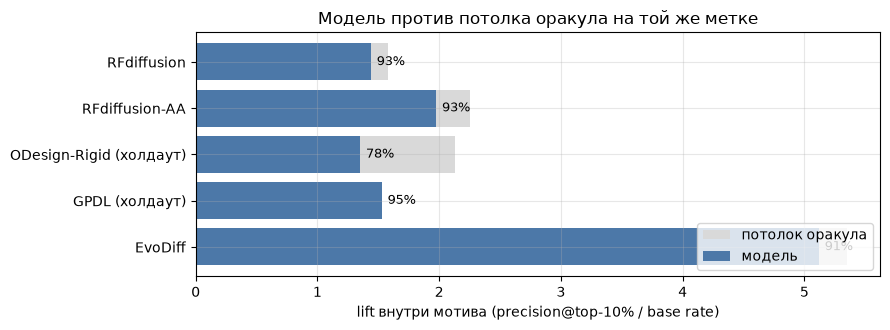

,Spearman,lift,потолок,доля потолка,мотивов
генератор,,,,,
RFdiffusion,0.59,1.44,1.58,93%,26
RFdiffusion-AA,0.66,1.97,2.25,93%,23
ODesign-Rigid (холдаут),0.38,1.35,2.13,78%,25
GPDL (холдаут),0.63,1.53,1.53,95%,27
EvoDiff,0.84,5.12,5.35,91%,7


In [4]:
rl = load("results/analysis_relabel.json", "analysis.relabel")
if rl:
    rows = []
    for g in GENS:
        r = rl[g]["joint/min"]
        rows.append({
            "генератор": g + (" (холдаут)" if g in HOLDOUT else ""),
            "Spearman": round(r["median_spearman"], 3),
            "lift": r["median_model_lift_vs_B"],
            "потолок": r["median_oracle_lift_vs_B"],
            "доля потолка": r["frac_of_ceiling"],
            "мотивов": r["n_kept_motifs"],
        })
    df = pd.DataFrame(rows).set_index("генератор")

    fig, ax = plt.subplots(figsize=(9, 3.4))
    y = range(len(df))
    ax.barh(y, df["потолок"], color="#d9d9d9", label="потолок оракула")
    ax.barh(y, df["lift"], color="#4c78a8", label="модель")
    ax.set_yticks(list(y), df.index)
    for i, (m, c) in enumerate(zip(df["lift"], df["доля потолка"])):
        ax.text(m + 0.05, i, f"{c:.0%}", va="center", fontsize=9)
    ax.set_xlabel("lift внутри мотива (precision@top-10% / base rate)")
    ax.set_title("Модель против потолка оракула на той же метке")
    ax.legend(loc="lower right")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

    display(df.assign(**{"доля потолка": df["доля потолка"].map("{:.0%}".format)}).round(2))

На четырёх генераторах из пяти модель забирает 88–97% доступного сигнала: остаток там
упирается в шум самой метки, а не в архитектуру. **ODesign-Rigid — единственное место
с существенным запасом** (74%).

Абсолютные значения lift между метками несопоставимы: под `min` базовая доля
дизайнируемых выше, а lift арифметически ограничен $1/\mathrm{base\_rate}$. Сравнивать
нужно долю потолка.

## 3. Дешёвые бейзлайны

Бьём ли мы вообще что-то, кроме тривиальных геометрических дескрипторов? Бейзлайнам
дана фора: направление ранжирования выбирается лучшее из двух на каждом генераторе.

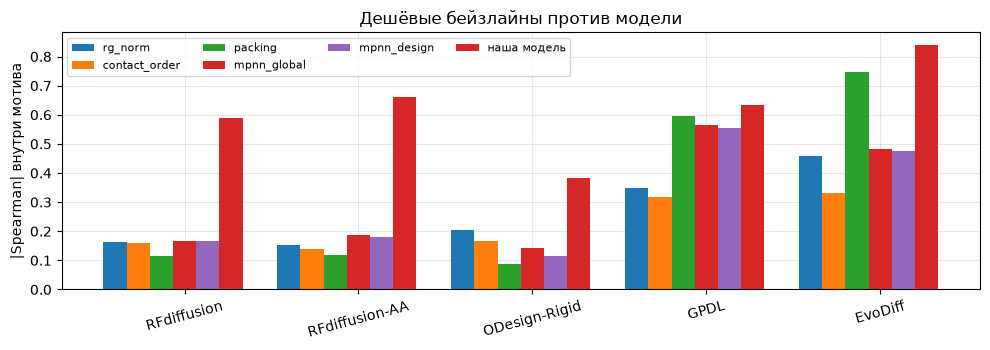

,rg_norm,contact_order,packing,mpnn_global,mpnn_design,наша модель
RFdiffusion,0.164,0.158,0.115,0.167,0.168,0.588
RFdiffusion-AA,0.151,0.139,0.118,0.187,0.180,0.663
ODesign-Rigid,0.206,0.167,0.089,0.142,0.117,0.382
GPDL,0.349,0.318,0.595,0.564,0.555,0.635
EvoDiff,0.457,0.333,0.748,0.483,0.477,0.841


In [5]:
bl = load("results/analysis_baselines.json", "analysis.baselines")
if bl:
    names = [k for k in bl[GENS[0]] if bl[GENS[0]][k]["lift"] is not None]
    mat = pd.DataFrame(
        {g: {n: bl[g][n]["abs_spearman"] for n in names} for g in GENS}
    ).T[names]

    fig, ax = plt.subplots(figsize=(10, 3.6))
    x = range(len(GENS))
    w = 0.8 / len(names)
    for j, n in enumerate(names):
        is_model = n == "наша модель"
        ax.bar([i + j * w for i in x], mat[n], width=w, label=n,
               color="#d62728" if is_model else None, zorder=3 if is_model else 2)
    ax.set_xticks([i + 0.4 for i in x], GENS, rotation=15)
    ax.set_ylabel("|Spearman| внутри мотива")
    ax.set_title("Дешёвые бейзлайны против модели")
    ax.legend(fontsize=8, ncol=4)
    plt.tight_layout()
    plt.show()

    display(mat.round(3))

Выигрыш 5/5, но структура отрыва важнее факта. **На слабых генераторах модель почти
не нужна:** на EvoDiff и GPDL тривиальная плотность контактов подбирается вплотную —
такие остова валятся очевидным образом. **На сильных генераторах бейзлайны бесполезны:**
на RFdiffusion и RFdiffusion-AA все дескрипторы падают до уровня шума, потому что
все выходы поверхностно безупречны и компактностью не разделяются.

Ценность модели сосредоточена ровно в том режиме, ради которого фильтр и строится.

## 4. Второй оракул: не выучили ли мы причуды ESMFold

MotifBench свернул **те же восемь последовательностей** ещё и AlphaFold2. Модель обучена
на ESMFold и AF2 никогда не видела.

In [6]:
so = load("results/analysis_second_oracle.json", "analysis.second_oracle")
if so:
    rows = []
    for g, r in so.items():
        rows.append({
            "генератор": g + (" (холдаут)" if g in HOLDOUT else ""),
            "согласие оракулов": round(r["sp_esm_af2"], 3),
            "модель ↔ ESMFold": round(r["sp_model_esm"], 3),
            "модель ↔ AF2": round(r["sp_model_af2"], 3),
            "доля потолка ESM": f"{r['frac_ceiling_esm']:.0%}",
            "доля потолка AF2": f"{r['frac_ceiling_af2']:.0%}",
            "разрыв свой−чужой": f"{r['gap_median']:+.3f} "
                                 f"[{r['gap_ci90'][0]:+.3f}, {r['gap_ci90'][1]:+.3f}]",
        })
    display(pd.DataFrame(rows).set_index("генератор"))

,согласие оракулов,модель ↔ ESMFold,модель ↔ AF2,доля потолка ESM,доля потолка AF2,разрыв свой−чужой
генератор,,,,,,
RFdiffusion,0.692,0.563,0.498,86%,83%,"+0.046 [+0.024, +0.067]"
GPDL (холдаут),0.817,0.645,0.648,90%,81%,"+0.001 [-0.015, +0.034]"


**Два оракула расходятся между собой сильнее, чем модель расходится между ними.**
Если бы мы выучили идиосинкразию ESMFold, асимметрия была бы резкой; она есть, но мала
и измерена — 4–7% сигнала (интервал разрыва не накрывает ноль, но сам разрыв порядка
0.02–0.04 при Spearman 0.54–0.66).

## 5. Экономика: сколько это экономит

Метрика — сколько дорогих проверок нужно до первого рабочего остова. Это то решение,
которое принимается на практике: проверять кандидатов, пока один не сработает.

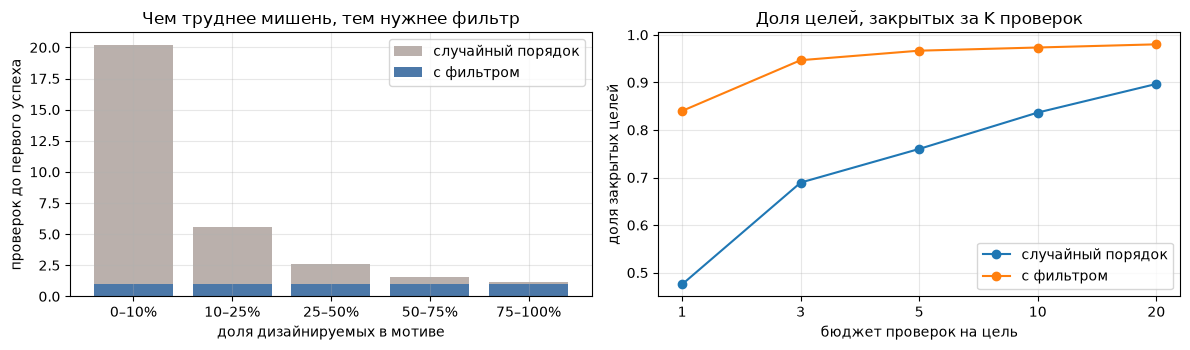

,мотивов,случайно,с фильтром,выигрыш
0–10%,27.0,20.20,1.0,16.83
10–25%,23.0,5.61,1.0,4.59
25–50%,19.0,2.59,1.0,2.35
50–75%,41.0,1.53,1.0,1.51
75–100%,37.0,1.13,1.0,1.13


In [7]:
ec = load("results/analysis_economics.json", "analysis.economics")
if ec and os.path.exists("results/economics_per_motif.csv"):
    bd = pd.DataFrame(ec["by_difficulty"]).T
    bd.index = ["0–10%", "10–25%", "25–50%", "50–75%", "75–100%"][: len(bd)]

    fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
    axes[0].bar(bd.index, bd["median_first_random"], color="#bab0ac", label="случайный порядок")
    axes[0].bar(bd.index, bd["median_first_model"], color="#4c78a8", label="с фильтром")
    axes[0].set_ylabel("проверок до первого успеха")
    axes[0].set_xlabel("доля дизайнируемых в мотиве")
    axes[0].set_title("Чем труднее мишень, тем нужнее фильтр")
    axes[0].legend()

    b = pd.DataFrame(ec["budgets"]).T
    axes[1].plot(b.index, b["random"], marker="o", label="случайный порядок")
    axes[1].plot(b.index, b["model"], marker="o", label="с фильтром")
    axes[1].set_xlabel("бюджет проверок на цель")
    axes[1].set_ylabel("доля закрытых целей")
    axes[1].set_title("Доля целей, закрытых за K проверок")
    axes[1].legend()
    plt.tight_layout()
    plt.show()

    display(bd.rename(columns={
        "n_motifs": "мотивов", "median_first_random": "случайно",
        "median_first_model": "с фильтром", "median_speedup": "выигрыш",
    }).round(2))

**Средняя цифра по бенчмарку вводит в заблуждение в обе стороны.** MotifBench состоит
преимущественно из лёгких мишеней — 78 мотивов из 147 имеют базовую долю выше 50%,
где случайный выбор срабатывает с первой-второй попытки и фильтр не нужен.

В регионе, ради которого он строился — трудные мишени, где из ста кандидатов работают
единицы, — экономия достигает 91% при 16.8× сокращении числа проверок. Одна дорогая
проверка (8 рефолдов ESMFold) стоит 2300–13800 прогонов фильтра, поэтому его
собственная стоимость на баланс не влияет.

Честные оговорки: на 3% мотивов фильтр хуже случайного порядка (на ODesign-Rigid — 13%);
на 3 мотивах из 150 дизайнируемых нет вообще, и распознавать такие цели заранее модель
не умеет.

## 6. Test-подвыборка: сравнение архитектур

Историческая часть — метрики на синтетических декоях. После очистки данных задача
насыщается (AUC 1.0000 у всех трёх архитектур), поэтому содержательная оценка давно
смещена в OOD-разделы выше. Блок оставлен для полноты.

In [8]:
archs = {}
for name, path in [("hybrid", "results/eval_results_hybrid.json"),
                   ("mlp", "results/eval_results_mlp.json"),
                   ("gps", "results/eval_results_gps.json")]:
    if os.path.exists(path):
        archs[name] = json.load(open(path))["fold"]

if archs:
    display(pd.DataFrame(archs).T[
        ["accuracy", "roc_auc", "pr_auc", "ece", "precision", "recall"]].round(4))
else:
    print("нет results/eval_results_*.json — запустите: python -m evaluation.eval_model")

,accuracy,roc_auc,pr_auc,ece,precision,recall
hybrid,0.9981,0.9999,0.9999,0.0017,0.9965,0.9989
mlp,0.9978,1.0000,0.9999,0.0015,0.9969,0.9980
gps,0.9988,0.9999,0.9999,0.0010,0.9979,0.9993


Полные таблицы и интерпретация — в [05 — Эксперименты и результаты](../docs/05-eksperimenty-i-rezultaty.md).